.\.venv\Scripts\Activate.ps1      

In [1]:
import sys
print(sys.executable)

c:\Desktop\Python\CarnaticAnnotater\demucs_env\Scripts\python.exe


In [2]:
import sys
import os
import importlib
from pathlib import Path
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Tuple, Union
import random
import json
import ast
import re
import tensorflow as tf
from tqdm import tqdm
from fastdtw import fastdtw
from sklearn.cluster import AgglomerativeClustering
import IPython.display as ipd
import ipywidgets as widgets


In [11]:
carnatic_dir = r"C:\Desktop\Python\CarnaticAnnotater\VocalAnnotator"
if carnatic_dir not in sys.path:
    sys.path.append(carnatic_dir)

import carnatic_functions
importlib.reload(carnatic_functions)

from carnatic_functions import (

    AUDIO_CONFIG,
    CREPE_CONFIG,
    SongReconstructionWidget,

    # --- UTILITY FUNCTIONS ---
    cluster_curve,
    evaluate_cluster,
    plot_tertiary_summary,
    play_segment,
    annotate_clusters_widget,
    explore_syllables,

    primary_clustering_pca,
    plot_cluster,
    play_song_with_breaks,
    secondary_clustering_dtw,
    secondary_clustering_pca,
    tertiary_clustering_pca,
    plot_single_tertiary_cluster,

)

# --- CONFIGURATION ---
raaga_dir = r"C:\Desktop\Python\CarnaticAnnotater\Raagas\Shanmukhapriya"

if not os.path.exists(raaga_dir):
    print(f"❌ Error: Raaga Directory not found: {raaga_dir}")
else:
    raaga_name = os.path.basename(raaga_dir)
    print(f"🎵 Configured for Raaga: {raaga_name}")

    vocal_dir = os.path.join(raaga_dir, f"{raaga_name}_Vocals")
    csv_dir = os.path.join(raaga_dir, f"{raaga_name}_CSVs")
    data_dir = os.path.join(raaga_dir, f"{raaga_name}_Data")

    audio_dir = vocal_dir 


    context = {
        "raaga_name": raaga_name,
        "crepe_csv": os.path.join(data_dir, f"crepe_{raaga_name}.csv"),
        "carva_csv": os.path.join(data_dir, f"carva_{raaga_name}.csv"),
        "log_csv": os.path.join(data_dir, f"log_{raaga_name}.csv")
    }
    carva_csv_path = context["carva_csv"]

    print(f"✅ Context Manually Set:")
    print(f"   📂 Vocal Dir: {vocal_dir}")
    print(f"   📂 Data Dir:  {data_dir}")
    print(f"   📄 Carva CSV: {carva_csv_path}")

print("✅ All libraries and functions imported successfully!")

CONFIG = {
    "initial_window_size": 60,
    "decay_size": 2,
    "min_window_size": 20,
    "hop_factor": 6,
    "outlier_threshold": 2,
    "similarity_threshold": 0.6,
    "pca_components": 10,
    "second_phase_window_size": 64,
    "similarity_threshold_secondary": 0.9,
    "similarity_threshold_tertiary": 0.9,
    "pca_components_secondary": 10
}

🎵 Configured for Raaga: Shanmukhapriya
✅ Context Manually Set:
   📂 Vocal Dir: C:\Desktop\Python\CarnaticAnnotater\Raagas\Shanmukhapriya\Shanmukhapriya_Vocals
   📂 Data Dir:  C:\Desktop\Python\CarnaticAnnotater\Raagas\Shanmukhapriya\Shanmukhapriya_Data
   📄 Carva CSV: C:\Desktop\Python\CarnaticAnnotater\Raagas\Shanmukhapriya\Shanmukhapriya_Data\carva_Shanmukhapriya.csv
✅ All libraries and functions imported successfully!


In [10]:
primary_clustering_pca(audio_dir,CONFIG,verbose=True, force_clean=True)
secondary_clustering_pca(audio_dir,CONFIG,verbose=True)
tertiary_clustering_pca(audio_dir, CONFIG,verbose=True)

🧹 Running Audio Preprocessing (Clean)...
🧹 Starting Audio Cleaning for Shanmukhapriya (Per Song Filter)...


Cleaning Songs:  12%|█▎        | 1/8 [00:00<00:03,  1.80it/s]

   [Song 0] Median Freq: 236.06, Median Amp: 0.0329


Cleaning Songs:  25%|██▌       | 2/8 [00:01<00:03,  1.88it/s]

   [Song 1] Median Freq: 255.67, Median Amp: 0.0028


...

Cleaning Songs: 100%|██████████| 8/8 [00:07<00:00,  1.13it/s]


   [Song 7] Median Freq: 350.55, Median Amp: 0.0099
✅ Cleaned data saved to C:\Desktop\Python\CarnaticAnnotater\Shanmukhapriya\Shanmukhapriya_Data\crepe_Shanmukhapriya_clean.csv
📂 Using Cleaned CREPE Data: crepe_Shanmukhapriya_clean.csv
🔍 Starting full clustering for Shanmukhapriya...
   (Wiping old data for full run)


Processing all songs (Sequential): 100%|██████████| 8/8 [00:20<00:00,  2.51s/it]


✅ Clustering finished. Saved 3778 segments to C:\Desktop\Python\CarnaticAnnotater\Shanmukhapriya\Shanmukhapriya_Data\carva_Shanmukhapriya.csv (Column: Primary_Label)
🔬 Starting PCA re-clustering for 'Shanmukhapriya'...
   -> Targeting ALL songs.
   -> Found 3778 valid segments.
   -> Large dataset (3778 segments). Switching to BIRCH clustering for speed.
✅ Updated C:\Desktop\Python\CarnaticAnnotater\Shanmukhapriya\Shanmukhapriya_Data\carva_Shanmukhapriya.csv with 1668 new PCA clusters (ordered by size).
🔬 Starting Tertiary (Meta) Clustering...
   -> Analyzing 1668 Secondary Clusters...
   -> Grouping 1668 clusters by Shape Similarity (Threshold=0.9)...
✅ Tertiary Clustering Complete. Mapped 1668 clusters -> 125 shapes (ordered by size).


,Index,AudioPath,SegmentList,StartFrame,EndFrame,Primary_Label,Secondary_Label,Tertiary_Label
0,0,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.037204037428992, 1.0053526561110508, 0.9613...",680,740,0,3,1
1,0,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.00539673298571, 1.01930974242864, 1.0106682...",820,880,0,3,1
2,0,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.017094397868325, 0.9983011698394372, 0.9846...",1230,1290,0,3,1
3,0,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.0168395492385855, 1.0139243990693572, 1.013...",1290,1350,0,3,1
4,0,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.006895256500207, 1.0042957852239356, 1.0002...",1470,1530,0,3,1
...,...,...,...,...,...,...,...,...
3773,7,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.0106265436461703, 0.9939936808562394, 0.994...",3840,3862,47,132,1
3774,7,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.0365403026282851, 1.093927295508293, 1.0993...",669,689,48,1665,4
3775,7,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.1783941237813398, 1.144954540711251, 1.1331...",4965,4985,48,1666,4
3776,7,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.5328377607688095, 1.4858547642690711, 1.492...",5034,5054,65,1667,2


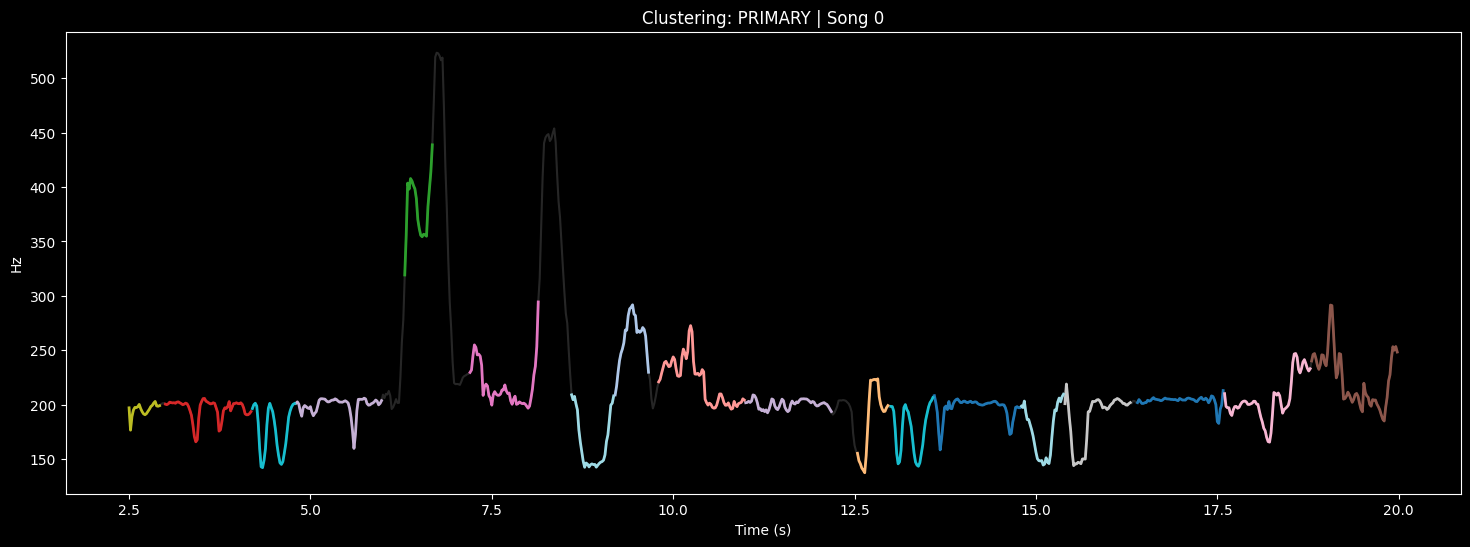

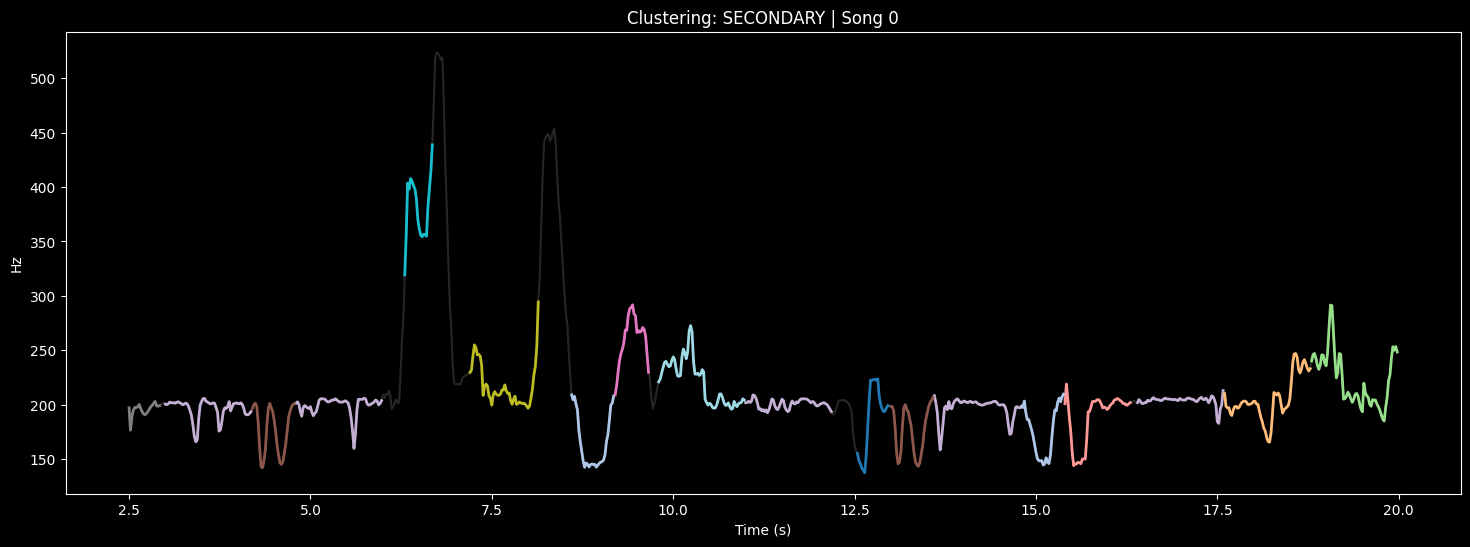

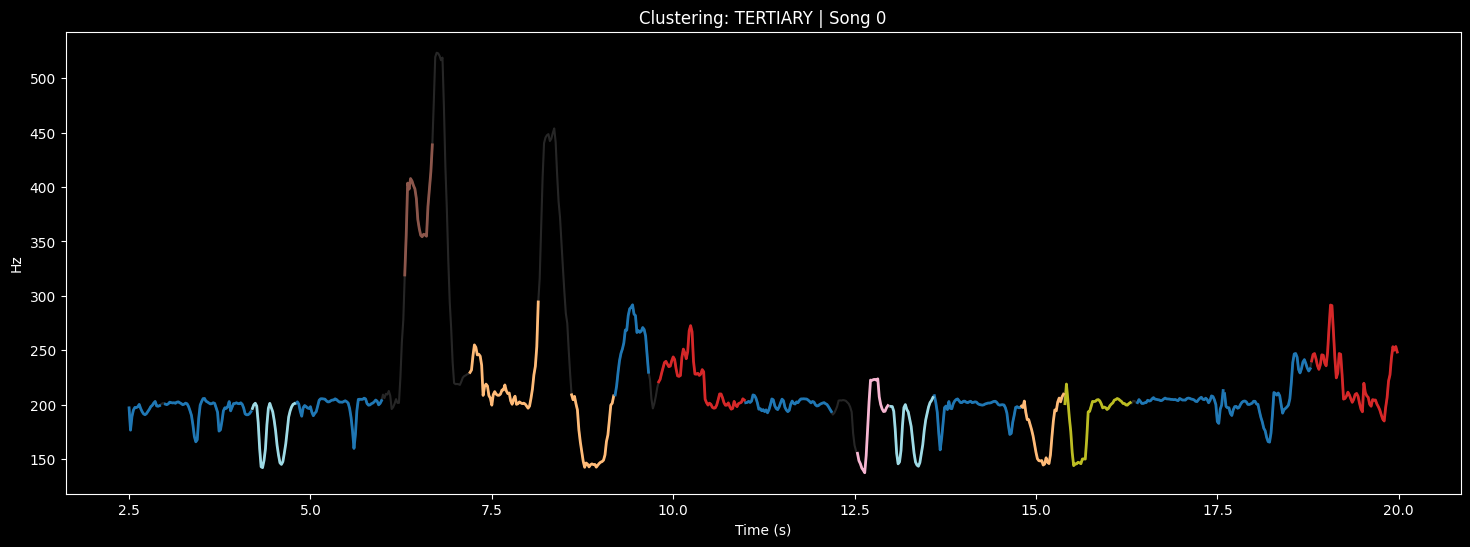

In [7]:
start_time = 2.5
end_time = 20
song_index = 0
#cluster_curve(audio_dir, 0, mode='syllable', start_time=start_time, end_time=end_time)
cluster_curve(audio_dir, song_index=song_index, mode='primary', start_time=start_time, end_time=end_time)
cluster_curve(audio_dir, song_index=song_index, mode='secondary', start_time=start_time, end_time=end_time)
cluster_curve(audio_dir, song_index=song_index, mode='tertiary', start_time=start_time, end_time=end_time)

In [12]:
import importlib
import interactive_viewer 
importlib.reload(interactive_viewer)

from interactive_viewer import view_primary_segments_interactive
# ...

csv_file = r"C:\Desktop\Python\CarnaticAnnotater\Raagas\Shanmukhapriya\Shanmukhapriya_Data\carva_Shanmukhapriya.csv"
view_primary_segments_interactive(song_index=2, csv_path=csv_file)

🎵 Auto-selected Raga: Shanmukhapriya
   Allowed Notes: ['Da1', "Da1'", 'Da1_', 'Ga2', "Ga2'", 'Ga2_', 'Ma2', "Ma2'", 'Ma2_', 'Ni2', "Ni2'", 'Ni2_', 'Pa', "Pa'", 'Pa_', 'Ri2', "Ri2'", 'Ri2_', 'Sa', "Sa'", 'Sa_']


    'data': [{'line': {'color': 'cyan', 'width': 3},
              'mode': 'line…

📊 Plotting 2 segments from primary cluster 20


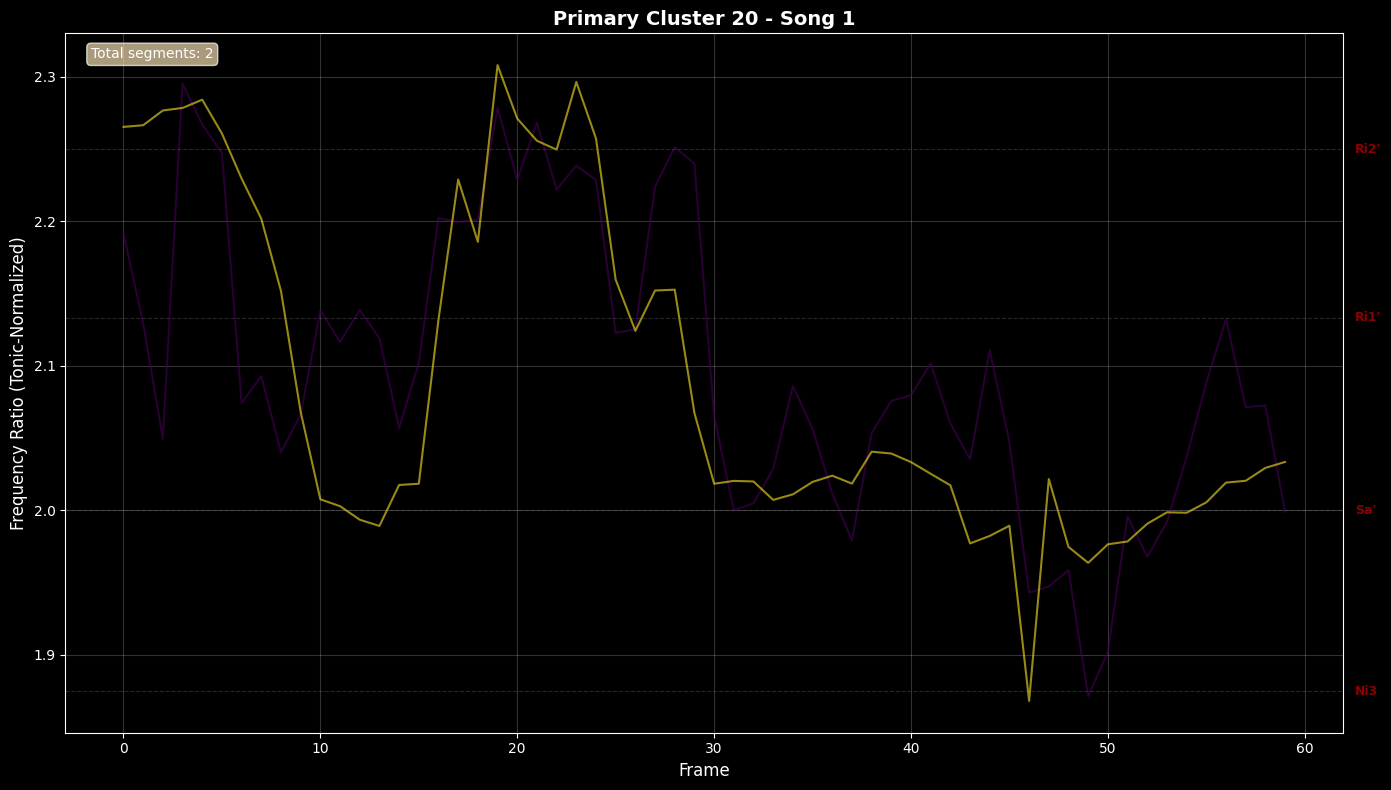

🔇 No audio preview available.
📊 Plotting 3 segments (sampled 30.0% from 10 total) from secondary cluster 20


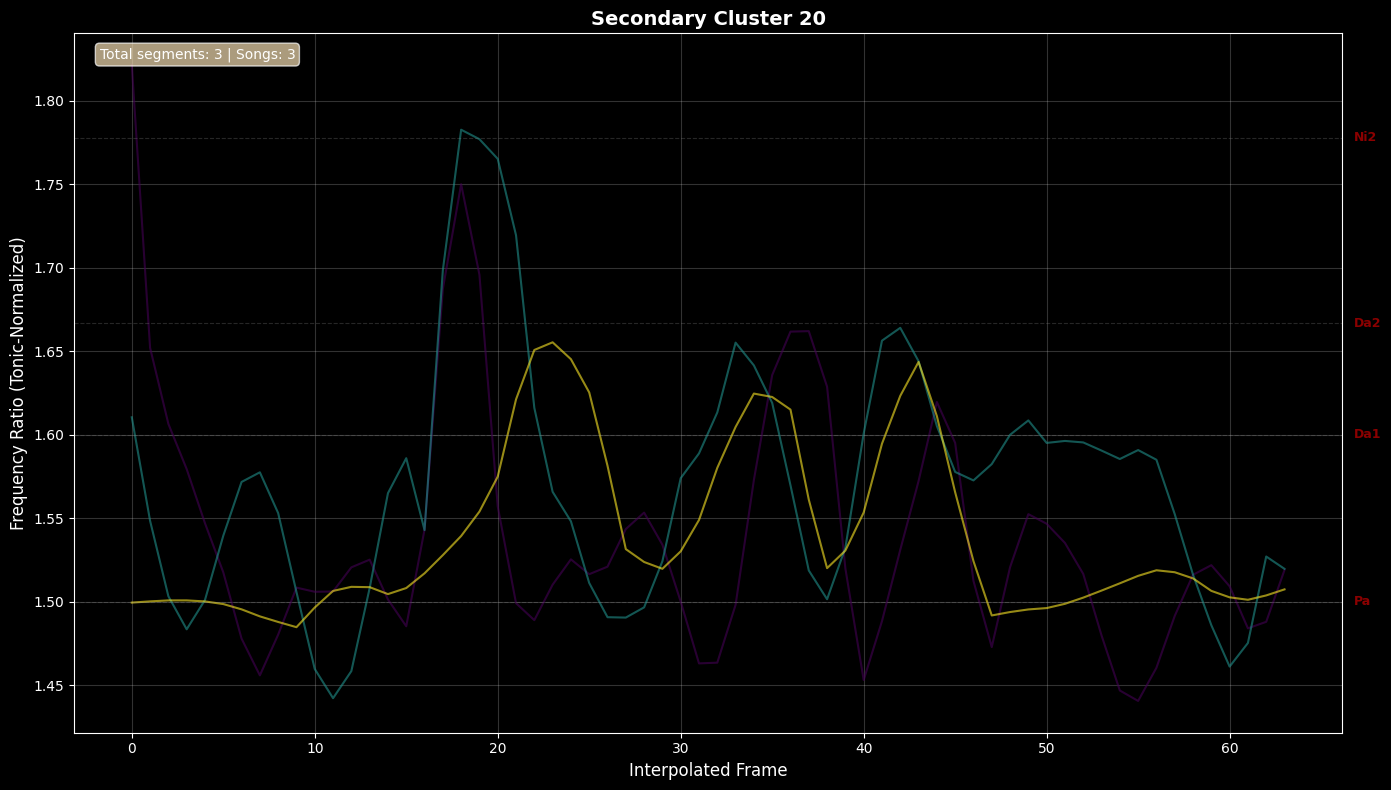

🔊 Audio Previews (Top 3):


,Index,AudioPath,SegmentList,StartFrame,EndFrame,Primary_Label,Secondary_Label,Tertiary_Label
2322,4,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.821233883608553, 1.6404952986697077, 1.6014...",23600,23660,70,20,1
550,1,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.6103793226059202, 1.5441861283127585, 1.497...",8510,8570,22,20,1
1870,3,C:\Desktop\Python\CarnaticAnnotater\Shanmukhap...,"[1.4994271288751877, 1.5007273873152682, 1.500...",12114,12150,97,20,1


In [13]:
plot_cluster(20, order='primary',song_index=1, raaga_dir=raaga_dir)
plot_cluster(20, order='secondary', raaga_dir=raaga_dir,density=0.3)
# plot_cluster(19, order='tertiary', raaga_dir=raaga_dir,density=0.05, normalize=True)


In [14]:
import importlib
import carnatic_functions
importlib.reload(carnatic_functions)

# Path to your carva.csv
# Update this path if it's different!
csv_path = "C:\Desktop\Python\CarnaticAnnotater\Mayamalavagowlai\Mayamalavagowlai_Data\carva_Mayamalavagowlai.csv"

# Run the widget
# tertiary_id = 0 (e.g., small cluster group)
# secondary_id = 42 (specific cluster ID)
# segment_index = 0 (first segment in that cluster)
carnatic_functions.secondary_cluster_widget(csv_path, secondary_id=42, segment_index=0)

<>:7: SyntaxWarning:

invalid escape sequence '\D'

<>:7: SyntaxWarning:

invalid escape sequence '\D'

C:\Users\nandh\AppData\Local\Temp\ipykernel_29820\460974143.py:7: SyntaxWarning:

invalid escape sequence '\D'

C:\Users\nandh\AppData\Local\Temp\ipykernel_29820\460974143.py:7: SyntaxWarning:

invalid escape sequence '\D'



TypeError: secondary_cluster_widget() missing 1 required positional argument: 'tertiary_id'

In [ ]:
play_segment(
    audio_dir=r"C:\Desktop\Python\CarnaticAnnotater\data\Mayamalavagowlai", 
    song_index=18,       # The song index from your CSV/Plot
    start_frame=29666,    # Starting Frame
    end_frame=29708,      # Ending Frame
    plot=True,          # Show the Pitch Curve?
    spectrogram=True,   
    synthesize=True,   # <--- Synthesize instead of real audio
    tonic="D3" # Show the Spectrogram?
)